# Example: N-Ary Recombining Lattice Models
In the binomial example, we represented daily price changes using one up factor and one down factor. What changes if we allow more than two possible price movements at each step? An N-ary lattice allows $m$ possible price movements at each step.

> __Learning Objectives__
>
> By the end of this example, you will be able to:
>
> * **Estimate N-ary lattice parameters from historical data.** Group observed growth rates into bins and calculate a representative price-change factor and probability for each branch.
> * **Construct an N-ary recombining lattice.** Allow $m$ possible price movements at each step and use branch counts to calculate the price at each node.
> * **Compute and interpret terminal probability distributions.** Use the multinomial distribution to calculate node probabilities, verify that they sum to one, and interpret the outcomes in terms of share prices and annualized log-growth rates.

Let's get started!

___


## Setup, Data, and Prerequisites
First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project, defines local paths, and loads the packages used here.

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # load the local notebook setup

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) for the functions and types used here.

### Data
The dataset contains daily open-high-low-close (OHLC) records for firms in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) from 2014-01-03 through 2024-12-31, along with records for several exchange-traded funds and volatility products.

Let's load the data using [the MyTrainingMarketDataSet(...) function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet). We store the result in `original_dataset`, a dictionary whose keys are ticker symbols and whose values are `DataFrame` tables containing each ticker's price history.


In [2]:
original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"]; # ticker => historical price table

Not all tickers have the same number of observations. For this example, let's keep price histories of equal length. We use `AAPL` as our reference and store its number of records in `maximum_number_trading_days`. We will then retain tickers with that same number of records.


In [3]:
maximum_number_trading_days = original_dataset["AAPL"] |> nrow # reference number of daily price records

2767

Now, let's collect the price histories with `maximum_number_trading_days` records. We store them in the `dataset` dictionary:


In [4]:
dataset = let

    # Initialize the retained price histories -
    dataset = Dict{String, DataFrame}();

    # Matching record counts do not by themselves verify matching dates.
    for (ticker, data) ∈ original_dataset
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset;
end;

Finally, let's collect and alphabetically sort the ticker symbols in our cleaned dataset. We store them in `list_of_tickers`.


In [5]:
list_of_tickers = keys(dataset) |> collect |> sort # alphabetical ticker order

424-element Vector{String}:
 "A"
 "AAL"
 "AAP"
 "AAPL"
 "ABBV"
 "ABT"
 "ACN"
 "ADBE"
 "ADI"
 "ADM"
 ⋮
 "WYNN"
 "XEL"
 "XOM"
 "XRAY"
 "XYL"
 "YUM"
 "ZBRA"
 "ZION"
 "ZTS"

### Constants
Let's set the constants we'll use in this notebook. The comments describe their meaning and units.


In [6]:
TSIM = 16; # holding period N, in trading days; use a positive integer
Δt = (1.0/252); # step size: 1 trading day in units of years
m = 3; # number of branches; use an integer ≥ 2
binning_method = :equalwidth; # :equalwidth or :quantile
price_interval_width = 2.0; # share-price interval width for the plot, in USD/share; must be positive
growth_interval_width = 0.5; # annualized log-growth interval width for the plot, in 1/year; must be positive

### Helper Functions
We'll use two helper functions to locate the nodes at a chosen lattice level:

* [The nodes_at_level(...) function](docs/nary-level-indexing.md#nodes_at_level) returns the number of branch-count states at that level.
* [The level_offset(...) function](docs/nary-level-indexing.md#level_offset) returns the first node ID at that level.

Node IDs start at zero. In these functions, `i` is the level, corresponding to $t$ in the lecture, and `m` is the number of branches.


In [7]:
nodes_at_level(i::Integer, m::Integer) = binomial(i + m - 1, i); # number of branch-count states at level i
level_offset(i::Integer, m::Integer) = i == 0 ? 0 : binomial(i + m - 1, i - 1); # first zero-based node ID at level i

___

## Task 1: Estimate branch parameters from historical data
In this task, we estimate a price-change factor and probability for each branch from historical growth rates. We compare equal-width and quantile bins to examine how the binning method affects the model.

First, let's choose a firm using `selected_firm_ticker` and retrieve its price history from `dataset`. We store that history in `selected_firm_data`.


In [8]:
selected_firm_ticker = "AAPL"
selected_firm_index = findfirst(x-> x == selected_firm_ticker, list_of_tickers);
selected_firm_data = dataset[selected_firm_ticker];

Let's choose the starting day for our lattice using `start_index`. The volume-weighted average price (VWAP) on that day gives us the initial share price $S_0$. The terminal level is `TSIM` trading days later.

Here, we estimate the branch parameters using the full historical sample, including observations after our starting day. Thus, this example illustrates the lattice calculation using historical estimates; it does not test a forecast made using only information available on that day.


In [9]:
start_index = 1465; # row supplying the initial VWAP; keep start_index + TSIM within the data
stop_index = start_index + TSIM
println("Visualize $(selected_firm_ticker) between trading days ($(start_index) -> $(stop_index))")

Visualize AAPL between trading days (1465 -> 1481)


### Compute historical growth rates
For consecutive observed prices $S_{j-1}$ and $S_j$, the annualized log-growth rate is given by:

$$
g_j=\frac{1}{\Delta t}\ln\!\left(\frac{S_j}{S_{j-1}}\right).
$$

We use daily VWAP observations with $\Delta t=1/252$ years. Positive growth indicates a price increase; negative growth indicates a decrease. The corresponding one-step price-change factor is $e^{g_j\Delta t}=S_j/S_{j-1}$.

[The log_growth_matrix(...) function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix) computes these growth rates for our selected firm. We store the observations in `log_growth_array`.


In [10]:
log_growth_array = log_growth_matrix(dataset, selected_firm_ticker); # annualized log-growth observations (1/year)

Let's look at the distribution of annualized log-growth rates for our selected firm. The histogram shows the range of historical observations that we will summarize using a small number of branches.


In [11]:
UnicodePlots.histogram(log_growth_array, nbins=21, closed=:left)

                  ┌                                        ┐ 
   [-22.0, -20.0) ┤▎ 3                                       
   [-20.0, -18.0) ┤  0                                       
   [-18.0, -16.0) ┤▏ 1                                       
   [-16.0, -14.0) ┤▎ 3                                       
   [-14.0, -12.0) ┤▌ 11                                      
   [-12.0, -10.0) ┤▋ 13                                      
   [-10.0,  -8.0) ┤█▍ 30                                     
   [ -8.0,  -6.0) ┤███▍ 73                                   
   [ -6.0,  -4.0) ┤███████▎ 159                              
   [ -4.0,  -2.0) ┤█████████████▋ 300                        
   [ -2.0,   0.0) ┤█████████████████████████████▍ 649        
   [  0.0,   2.0) ┤███████████████████████████████████  773  
   [  2.0,   4.0) ┤███████████████████▌ 431                  
   [  4.0,   6.0) ┤████████▊ 194                             
   [  6.0,   8.0) ┤███▏ 67                                   
   [  8.

### Estimate the branch factors and probabilities
Let's group the historical growth rates into $m$ intervals, called bins. Each bin will supply one representative price-change factor and its probability, giving us $m$ possible price movements at each step.

[The build_nary_lattice_from_growth_rate(...) function](docs/nary-branch-estimation.md#build_nary_lattice_from_growth_rate) performs three steps:

1. Group the observed growth rates into `m` bins using `binning_method`.
2. Within each bin, compute the factors $e^{g_j\Delta t}$ and average them. This gives one representative price-change factor $f_j$ for each branch.
3. Divide the number of observations in each bin by the total number of observations. These fractions give the branch probabilities $p_j$.

Thus, we average the **price-change factors**, rather than exponentiating an average growth rate. With `binning_method=:equalwidth`, the bins have equal width along the growth-rate axis, and bins containing more observations receive larger probabilities. Setting `binning_method=:quantile` places boundaries at empirical quantiles to give approximately equal observation counts.

We pass `Δt` as the `dt` argument so that annualized growth rates become one-day factors, and store the estimates in `result`.


In [12]:
result = build_nary_lattice_from_growth_rate(log_growth_array; n = m, dt = Δt, method = binning_method); # n is the estimator's branch-count keyword


Let's examine the estimated branches using [the print_lattice(...) function](docs/nary-branch-estimation.md#print_lattice). Each row shows a growth-rate bin, its representative price-change factor, its probability, and its observation count. A factor below one decreases the price, a factor above one increases it, and a factor of one leaves it unchanged.


In [13]:
print_lattice(result)

N-ary lattice (method=equalwidth, Δt=0.003968253968253968, observations=2766)
 -------- ------------------------- ---------- ------------- --------------
  branch           growth_interval     factor   probability   observations 
  String                    String    Float64       Float64          Int64 
 -------- ------------------------- ---------- ------------- --------------
      S1   [-21.211458, -6.905613)   0.961388      0.031092             86
      S2     [-6.905613, 7.400233)   1.001154      0.940709           2602
      S3     [7.400233, 21.706078]   1.040731      0.028200             78
 -------- ------------------------- ---------- ------------- --------------


### Compare the binning methods
How much does the choice of bins change our approximation? Let's compare equal-width and quantile bins using the same observations and the same number of branches. Equal-width bins divide the growth-rate range evenly; quantile bins aim to place equal numbers of observations in each bin.

We use [the build_nary_lattice_from_growth_rate(...) function](docs/nary-branch-estimation.md#build_nary_lattice_from_growth_rate) with each method.

__How much variability do we keep?__ Each branch replaces a range of historical growth observations with one value. We compare the historical one-step log growth with the growth represented by each branch:

$$
r_i=g_i\Delta t,
\qquad r_j^{\mathrm{branch}}=\ln f_j.
$$

The factor $f_j$ is an average of the observed factors $e^{r_i}$ in its bin. Taking the logarithm of that average generally does not give the average of the original growth values. Thus, we need to check both the mean and the variability of the resulting branch model.

We will compare the mean and standard deviation of one-day log growth, displayed in percent. We will also report:

$$
\text{Variance retained (\%)}=100\,
\frac{\text{variance of branch log growth}}{\text{variance of historical log growth}}.
$$

Each historical observation receives equal weight, while the branch values are weighted by their probabilities. We use the full observation count as the denominator of the historical variance.

The following code stores the branch estimates and summary statistics in `binning_comparison`. We first display the factors, probabilities, and observation counts, ordered from the smallest factor to the largest within each method.


In [14]:
binning_comparison = let
    # Keep the sample and branch count fixed while changing the binning method.
    growth = filter(isfinite, log_growth_array)
    observed_growth = growth .* Δt # one-step log growth r = g*Δt
    historical_mean = mean(observed_growth)
    historical_variance = mean((observed_growth .- historical_mean).^2) # denominator: full sample count
    estimates = Dict{Symbol, NamedTuple}()
    branches = DataFrame(method=String[], branch=Int[], factor=Float64[],
        probability_pct=Float64[], observations=Int[])
    moments = DataFrame(method=["Historical sample"],
        mean_growth_pct=[100*historical_mean],
        std_growth_pct=[100*sqrt(historical_variance)],
        variance_retained_pct=[historical_variance > 0 ? 100.0 : NaN])

    for (method, label) in [(:equalwidth, "Equal width"), (:quantile, "Quantile")]
        estimate = build_nary_lattice_from_growth_rate(growth; n=m, dt=Δt, method=method)
        estimates[method] = estimate
        for j in 1:m
            push!(branches, (label, j, estimate.avg_factor[j],
                100*estimate.freq[j], estimate.counts[j]))
        end

        # Use population variances so the historical and model weights are comparable.
        branch_growth = log.(estimate.avg_factor) # log growth represented by each factor
        model_mean = sum(estimate.freq .* branch_growth)
        model_variance = sum(estimate.freq .* (branch_growth .- model_mean).^2)
        # The variance ratio is undefined for a constant historical sample.
        retained = historical_variance > 0 ? 100*model_variance/historical_variance : NaN
        push!(moments, (label, 100*model_mean, 100*sqrt(model_variance), retained))
    end
    (estimates=estimates, branches=branches, moments=moments,
        growth=growth, historical_variance=historical_variance)
end;

# Round only the displayed values; subsequent calculations retain full precision.
let
    table = copy(binning_comparison.branches)
    table.factor = round.(table.factor; digits=6)
    table.probability_pct = round.(table.probability_pct; digits=2)
    pretty_table(table; table_format=TextTableFormat(borders=text_table_borders__compact))
end


 ------------- -------- ---------- ----------------- --------------
       method   branch     factor   probability_pct   observations 
       String    Int64    Float64           Float64          Int64 
 ------------- -------- ---------- ----------------- --------------
  Equal width        1   0.961388              3.11             86
  Equal width        2    1.00115             94.07           2602
  Equal width        3    1.04073              2.82             78
     Quantile        1   0.986115             33.33            922
     Quantile        2    1.00136             33.33            922
     Quantile        3    1.01562             33.33            922
 ------------- -------- ---------- ----------------- --------------


Let's see where the bins fall. Both panels show the same historical observations, expressed as one-day log growth $r_j=g_j\Delta t$ and displayed in percent. Dashed blue lines mark the internal bin boundaries. Solid red lines show the branch growth values $\ln f_j$, also displayed in percent. The probabilities attached to those branches are listed in the table above.


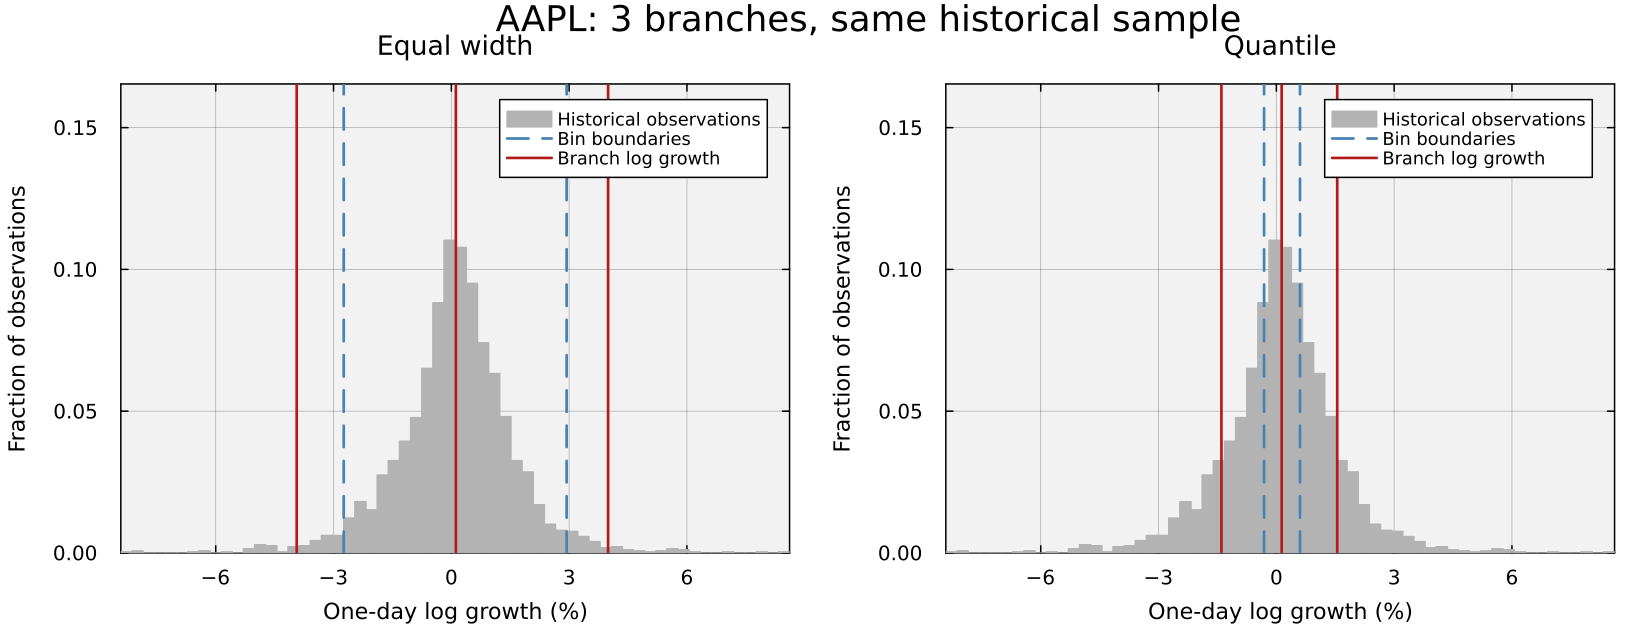

In [15]:
binning_comparison_plot = let
    # Use the same histogram and axes in both panels.
    daily_log_growth = 100 .* binning_comparison.growth .* Δt
    low, high = extrema(daily_log_growth)
    # Give a constant sample a nonzero plotting range -
    if low == high
        low -= 0.01
        high += 0.01
    end
    edges = collect(range(low, high; length=61))
    edges[end] = nextfloat(edges[end]) # include the largest observation
    histogram = StatsBase.fit(StatsBase.Histogram, daily_log_growth, edges; closed=:left)
    centers = (edges[1:end-1] .+ edges[2:end]) ./ 2
    fractions = histogram.weights ./ sum(histogram.weights) # fraction of observations in each bin
    panels = []

    for (method, label) in [(:equalwidth, "Equal width"), (:quantile, "Quantile")]
        estimate = binning_comparison.estimates[method]
        panel = Plots.bar(centers, fractions;
            bar_width=edges[2]-edges[1], color=:gray70, linecolor=:gray70,
            label="Historical observations", title=label,
            xlabel="One-day log growth (%)", ylabel="Fraction of observations",
            xlims=(low, high), ylims=(0, 1.5*maximum(fractions)),
            background_color_inside=:gray95, framestyle=:box, gridalpha=0.15,
            legend=:topright, legendfontsize=8, guidefontsize=10,
            tickfontsize=9, titlefontsize=12)
        Plots.vline!(panel, 100 .* estimate.edges[2:end-1] .* Δt;
            color=:steelblue, linestyle=:dash, linewidth=1.8, label="Bin boundaries")
        Plots.vline!(panel, 100 .* log.(estimate.avg_factor);
            color="#b31b1b", linewidth=1.8, label="Branch log growth")
        push!(panels, panel)
    end
    Plots.plot(panels...; layout=(1,2), size=(1100,420), dpi=150,
        plot_title="$(selected_firm_ticker): $(m) branches, same historical sample",
        left_margin=5*Plots.mm, right_margin=4*Plots.mm,
        bottom_margin=5*Plots.mm, top_margin=4*Plots.mm)
end


Let's now display the summary statistics stored in `binning_comparison.moments`. The table compares the mean and standard deviation of one-day log growth, displayed in percent, along with the percentage of historical variance represented by each model.


In [16]:
let
    # Mean and standard deviation are in percent; retained variance is a percentage ratio.
    table = copy(binning_comparison.moments)
    table.mean_growth_pct = round.(table.mean_growth_pct; digits=4)
    table.std_growth_pct = round.(table.std_growth_pct; digits=4)
    table.variance_retained_pct = round.(table.variance_retained_pct; digits=1)
    pretty_table(table; table_format=TextTableFormat(borders=text_table_borders__compact))
end


 ------------------- ----------------- ---------------- -----------------------
             method   mean_growth_pct   std_growth_pct   variance_retained_pct 
             String           Float64          Float64                 Float64 
 ------------------- ----------------- ---------------- -----------------------
  Historical sample            0.0924            1.477                   100.0
        Equal width            0.0986           0.9666                    42.8
           Quantile             0.096           1.2041                    66.5
 ------------------- ----------------- ---------------- -----------------------


The estimates preserve the historical mean price-change factor, but they do not generally preserve the mean or variance of log growth. Compare each model's mean and standard deviation with the historical sample. A similar mean does not necessarily imply a similar spread.

The retained-variance percentage compares the variability of branch log growth with the historical sample. Values below $100\%$ indicate less variability, while values above $100\%$ indicate more. A value close to $100\%$ indicates a close match in variance, but does not establish that the full distributions agree.

Replacing each bin's observations with one branch value removes the variation among observations within that bin. Compare the two methods to see how much variability each approximation represents. Equal branch probabilities alone do not establish that the model represents the historical growth distribution well.


___

## Task 2: Construct the recombining lattice
In this task, we use the branch factors estimated in Task 1 to construct an N-ary recombining lattice and calculate its node prices.

We use the estimates stored in `result`, which were computed using `binning_method`. Changing this setting and rerunning the calculations lets us see how the choice of bins affects the possible share prices and their probabilities.

From the lecture, a node at level $t$ has a branch-count vector $\mathbf{x}=(x_1,\ldots,x_m)$, where $x_j$ counts how often branch $j$ has occurred and $\sum_{j=1}^{m}x_j=t$. Its price is given by:

$$
S_t(\mathbf{x})=S_0\prod_{j=1}^{m}f_j^{x_j}.
$$

The order of the moves does not change this product. For example, taking branch 1 followed by branch 3 gives the same price as taking branch 3 followed by branch 1. Both paths have the same counts, so we represent them by one node. This is how the lattice recombines.

We construct a [MyGeneralAdjacencyRecombiningCommodityPriceTree](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.MyGeneralAdjacencyRecombiningCommodityPriceTree) and populate it using the initial VWAP and estimated factors. We store the model in `my_nary_lattice_model`. The code reverses the factors to put the largest first; later, we reverse the probabilities as well so each factor remains paired with its probability.


In [17]:
my_nary_lattice_model = let

    # Use the selected starting price and order factors from largest to smallest.
    model = nothing;
    Sₒ = selected_firm_data[start_index,:volume_weighted_average_price]; # initial VWAP (USD/share)
    Δ = result.avg_factor |> reverse; # one-step price-change factors, largest to smallest

    # Construct the node connections through the terminal level.
    model = build(MyGeneralAdjacencyRecombiningCommodityPriceTree, (
        n = m, # the model interface names the branch-count field n
        h = TSIM, # terminal level N, in trading-day steps
    ));

    # Assign a branch-count vector and price to each node.
    model = populate(model, Sₒ, Δ);

    # Report the initial condition.
    println("Starting price: $(Sₒ) USD for firm $(selected_firm_ticker)");

    model;
end;

Starting price: 62.0886 USD for firm AAPL


Let's look inside `my_nary_lattice_model`. We will use its `connectivity` field to inspect the branches and its `data` field to retrieve node prices and counts.


In [18]:
typeof(my_nary_lattice_model) |> T-> fieldnames(T) # inspect the lattice's stored fields

(:data, :connectivity, :h, :n)

The `connectivity` dictionary lists the next-level node IDs reachable from each node. Different parent nodes can share a child, reflecting the recombination of paths.

The current model also lists child IDs for terminal nodes, even though those children lie beyond the populated lattice. We stop at level `TSIM`; those extra IDs are not part of our calculation.


In [19]:
my_nary_lattice_model.connectivity

Dict{Int64, Vector{Int64}} with 969 entries:
  719 => [857, 858, 872]
  699 => [836, 837, 852]
  831 => [984, 985, 1002]
  319 => [400, 401, 410]
  687 => [823, 824, 840]
  185 => [242, 243, 251]
  823 => [976, 977, 994]
  420 => [516, 517, 525]
  525 => [636, 637, 645]
  365 => [456, 457, 470]
  638 => [764, 765, 774]
  263 => [333, 334, 341]
  422 => [518, 519, 527]
  242 => [310, 311, 320]
  183 => [239, 240, 249]
  551 => [666, 667, 671]
  224 => [290, 291, 302]
  694 => [830, 831, 847]
  692 => [828, 829, 845]
  ⋮   => ⋮

The `data` dictionary stores two quantities for each node:

* `price`: the node price in USD/share.
* `path`: the branch-count vector $\mathbf{x}$. Despite the field name, this records how often each branch occurred, rather than the order of the moves.

For example, with three branches, `[1, 0, 1]` identifies a level-two node reached by taking the first and third branches once each. Let's look at the stored prices and counts:


In [20]:
my_nary_lattice_model.data # path stores branch counts, not the order of moves

Dict{Int64, NamedTuple} with 969 entries:
  719 => (price = 70.7142, path = [5, 8, 2])
  699 => (price = 92.9253, path = [11, 3, 1])
  831 => (price = 65.7448, path = [1, 15, 0])
  319 => (price = 75.9301, path = [8, 0, 3])
  687 => (price = 86.1437, path = [8, 7, 0])
  185 => (price = 73.0028, path = [6, 1, 2])
  823 => (price = 89.6524, path = [9, 7, 0])
  420 => (price = 64.8687, path = [6, 1, 5])
  525 => (price = 62.364, path = [6, 1, 6])
  365 => (price = 96.4349, path = [11, 1, 0])
  638 => (price = 60.0616, path = [5, 3, 6])
  263 => (price = 55.5198, path = [1, 5, 4])
  422 => (price = 60.0289, path = [4, 3, 5])
  242 => (price = 75.9763, path = [7, 1, 2])
  183 => (price = 60.2444, path = [0, 8, 1])
  551 => (price = 45.4125, path = [2, 1, 10])
  224 => (price = 79.2583, path = [6, 4, 0])
  694 => (price = 65.669, path = [1, 14, 0])
  692 => (price = 70.9636, path = [3, 12, 0])
  ⋮   => ⋮

___

## Task 3: Compute and visualize the terminal distributions
In this task, we calculate the probability of reaching each terminal node and plot the resulting distributions of price and annualized log growth. We already have the possible prices at the end of our holding period; now we want to see how likely each outcome is.

### Find the terminal nodes
We use $N=$ `TSIM` as the terminal level. From the lecture, the number of branch-count states at level $t$ is given by:

$$
L_t=\binom{t+m-1}{m-1}.
$$

[The nodes_at_level(...) function](docs/nary-level-indexing.md#nodes_at_level) computes this count, while [the level_offset(...) function](docs/nary-level-indexing.md#level_offset) identifies the first node at that level. We use these values to collect the terminal node IDs in `nodes_at_tree_level`.


In [21]:
nodes_at_tree_level = let

    # Select the terminal level and its zero-based node IDs.
    l = TSIM; # terminal level N
    start = level_offset(l, m); # zero-based node ID of the first state at level l
    stop = start + nodes_at_level(l, m) - 1; # final zero-based node ID at this level

    # Collect the contiguous IDs for this level.
    nodes = range(start, stop=stop, step=1) |> collect;
end

153-element Vector{Int64}:
 816
 817
 818
 819
 820
 821
 822
 823
 824
 825
   ⋮
 960
 961
 962
 963
 964
 965
 966
 967
 968

### Compute the node probabilities
We assume independent branch choices with the same probabilities at every step. One ordered path with counts $\mathbf{x}$ has probability $\prod_{j=1}^{m}p_j^{x_j}$. Several different orderings can reach the same node, so we multiply by the number of such orderings:

$$
\mathbb P(\mathbf{X}_N=\mathbf{x})
=\underbrace{\frac{N!}{x_1!\cdots x_m!}}_{\substack{\text{number of}\\\text{orderings}}}
\;\times\;
\underbrace{\prod_{j=1}^{m}p_j^{x_j}}_{\substack{\text{probability of}\\\text{one ordering}}},
\qquad \sum_{j=1}^{m}x_j=N.
$$

This is the [multinomial distribution](https://juliastats.org/Distributions.jl/stable/multivariate/#Distributions.Multinomial). It extends the binomial calculation from two possible branches to $m$ branches. Here, $\mathbf{X}_N$ is the random vector of branch counts after $N$ steps.

Let's construct the probability model using [the Multinomial(...) function](https://juliastats.org/Distributions.jl/stable/multivariate/#Distributions.Multinomial). We supply `TSIM` steps and the branch probabilities `p`, storing the distribution in `d`. For each terminal node, we then evaluate the probability of its stored branch counts.

We collect the prices and probabilities in `data_array_at_level`, with one row per node, and sort the rows by price. The first column contains share prices; the second contains their node probabilities.


In [22]:
data_array_at_level = let
   
    # Store one row per node: price in column 1, probability in column 2.
    number_of_nodes = length(nodes_at_tree_level);
    results_array = Array{Float64, 2}(undef, number_of_nodes, 2);
    Δ = result.avg_factor |> reverse; # price-change factors, largest to smallest
    p = result.freq |> reverse; # historical probabilities in the same order as the model factors
    d = Multinomial(TSIM, p)

    for i ∈ 1:number_of_nodes
        
        # Retrieve each node using its zero-based ID.
        j = nodes_at_tree_level[i]; # Julia position i selects the zero-based node ID j
        nodemodel = my_nary_lattice_model.data[j]; # lattice data are keyed directly by zero-based node ID

        price = nodemodel.price; # terminal share price (USD/share)

        path = nodemodel.path; # counts in the same branch order as p
       
        # Include every ordering with these branch counts -
        results_array[i, 1] = price;
        results_array[i, 2] = pdf(d, path);
    end

    tmp = results_array[:,1];
    sorted_results_array = sortperm(tmp) |> I-> results_array[I, :]; # sort by price
end;

__Check:__ The terminal nodes account for every possible branch-count outcome, so their probabilities should sum to one. Let's verify this, allowing for floating-point rounding:


In [23]:
@assert data_array_at_level[:,2] |> sum ≈ 1.0 # terminal probabilities sum to one, within floating-point tolerance

### Visualize the share-price distribution
Let's show the terminal share-price distribution, as we did in the [L3b binomial example](../../week-3/L3b/CHEME-5660-L3b-LatticeModelSharePrice-RWPM-Example-Fall-2026.ipynb). Here, several outcomes can have nearly the same price, so we group prices into intervals and add the probabilities within each interval.

Each bar answers: what is the probability of finishing in this price range? Its height is the total probability in the interval, not a probability density. We set the interval width using `price_interval_width`. This changes how we display the outcomes; the lattice prices and node probabilities remain the same.


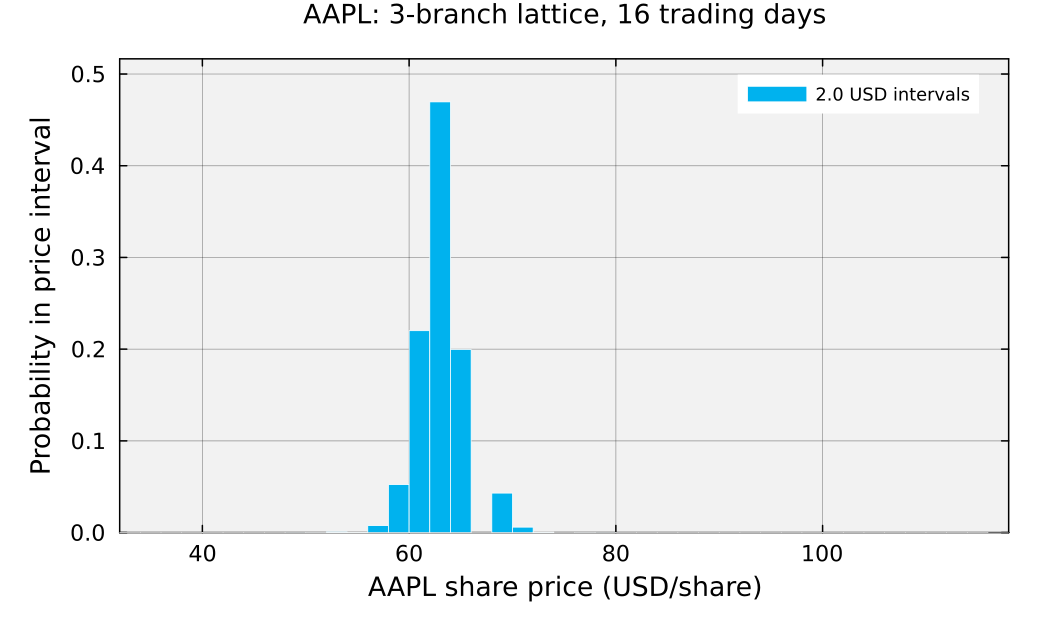

In [24]:
share_price_distribution_plot = let
    prices = data_array_at_level[:, 1]
    probabilities = data_array_at_level[:, 2]
    width = price_interval_width
    @assert isfinite(width) && width > 0 "price_interval_width must be finite and positive"

    # Cover the price range with equal-width intervals aligned to multiples of the width.
    lower_edge = width*floor(minimum(prices)/width)
    number_of_intervals = max(1, ceil(Int, (maximum(prices)-lower_edge)/width))
    edges = lower_edge .+ width .* collect(0:number_of_intervals)
    interval_probabilities = zeros(number_of_intervals)

    # Add node probabilities, rather than counting nodes; include the final upper edge.
    for (price, probability) in zip(prices, probabilities)
        index = clamp(searchsortedlast(edges, price), 1, number_of_intervals)
        interval_probabilities[index] += probability
    end
    @assert sum(interval_probabilities) ≈ sum(probabilities)
    centers = (edges[1:end-1] .+ edges[2:end])./2

    Plots.bar(centers, interval_probabilities;
        bar_width=width, color=:deepskyblue2, linecolor=:white, linewidth=0.5,
        label="$(width) USD intervals",
        xlabel="$(selected_firm_ticker) share price (USD/share)",
        ylabel="Probability in price interval",
        title="$(selected_firm_ticker): $(m)-branch lattice, $(TSIM) trading days",
        background_color_inside=:gray95, background_color_outside=:white,
        framestyle=:box, gridalpha=0.2, legend=:topright,
        foreground_color_legend=:transparent,
        xlims=(first(edges), last(edges)),
        ylims=(0, min(1.05, 1.1*maximum(interval_probabilities))),
        size=(700, 420), dpi=150,
        guidefontsize=12, tickfontsize=10, titlefontsize=12,
        left_margin=6*Plots.mm, bottom_margin=6*Plots.mm,
        right_margin=5*Plots.mm, top_margin=4*Plots.mm)
end


Let's identify a terminal node with the largest probability:

In [25]:
let
    i = argmax(data_array_at_level[:, 2]) # one node, not an aggregated price interval
    (price = data_array_at_level[i, 1],
     probability = data_array_at_level[i, 2])
end

(price = 63.244657174074675, probability = 0.37608140723014016)

We identified a terminal node with the largest probability. Compare this probability with the height of the bar containing its price. Why might that bar be taller?

The probability reported above belongs to one terminal node. The bar containing its price adds the probabilities of every node in that price interval. If the interval contains other nodes, the bar is taller; if it contains only this node, the two probabilities are equal. Changing the interval width changes which nodes are grouped together, while their individual prices and probabilities remain the same.


__What should we notice?__ The tallest bar identifies the price interval with the greatest probability. When one branch has a large probability, repeatedly taking that branch can concentrate the terminal outcomes in a narrow price range. For example, taking branch $j$ on all $N$ days has probability $p_j^N$ and gives price $S_0f_j^N$.

Compare the central bars with those farther away. Their heights reflect both our branch estimates and the price intervals used for the display. Wider intervals combine more outcomes, but do not change the underlying model.

__What happens as we take more steps?__ Let's try `TSIM = 8`, `20`, and `60`, rerunning the notebook after each change. Keep the firm, branch count, binning method, and price interval width fixed so we can isolate the effect of the holding period. How does the spread change, and does one interval still dominate? More steps allow more combinations of branch movements, helping the distribution fill out, although gaps between price clusters can remain.


### Express the outcomes as growth rates
We can describe these same outcomes using growth rates instead of prices. For a terminal price $S_N(\mathbf{x})$, the annualized log-growth rate over the holding period is given by:

$$
g_N(\mathbf{x})=\frac{1}{N\Delta t}\ln\!\left(\frac{S_N(\mathbf{x})}{S_0}\right).
$$

The elapsed time is $N\Delta t=$ `TSIM*Δt` years. Dividing by this time expresses the growth rate in inverse years; it does not extend the simulated holding period. We store the values in `growth_rate_array_at_level`, keeping the same node order as the price array.


In [26]:
growth_rate_array_at_level = let

    # Convert each terminal price to annualized log growth -
    Sₒ = selected_firm_data[start_index,:volume_weighted_average_price];
    elapsed_time = TSIM*Δt; # holding period in years
    log.(data_array_at_level[:,1]./Sₒ)./elapsed_time; # rates in 1/year; preserve the node order
end;

Let's group the annualized log-growth rates into intervals and add the node probabilities within each interval. Each bar shows the probability of finishing with a growth rate in that range. Negative growth corresponds to a terminal price below the starting price; positive growth corresponds to a price above it. We set the interval width using `growth_interval_width`.


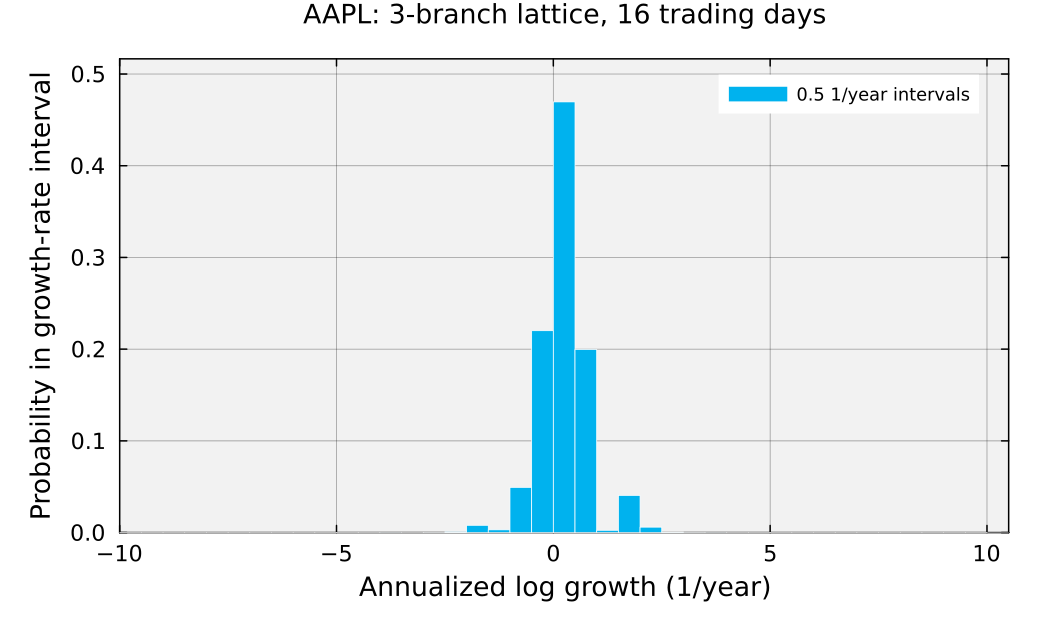

In [27]:
growth_rate_distribution_plot = let
    growth_rates = growth_rate_array_at_level
    probabilities = data_array_at_level[:, 2]
    width = growth_interval_width
    @assert isfinite(width) && width > 0 "growth_interval_width must be finite and positive"

    # Cover the growth-rate range with equal-width intervals.
    lower_edge = width*floor(minimum(growth_rates)/width)
    number_of_intervals = max(1, ceil(Int, (maximum(growth_rates)-lower_edge)/width))
    edges = lower_edge .+ width .* collect(0:number_of_intervals)
    interval_probabilities = zeros(number_of_intervals)

    # Add the node probabilities in each interval; include the final upper edge.
    for (growth, probability) in zip(growth_rates, probabilities)
        index = clamp(searchsortedlast(edges, growth), 1, number_of_intervals)
        interval_probabilities[index] += probability
    end
    @assert sum(interval_probabilities) ≈ sum(probabilities)
    centers = (edges[1:end-1] .+ edges[2:end])./2

    Plots.bar(centers, interval_probabilities;
        bar_width=width, color=:deepskyblue2, linecolor=:white, linewidth=0.5,
        label="$(width) 1/year intervals",
        xlabel="Annualized log growth (1/year)",
        ylabel="Probability in growth-rate interval",
        title="$(selected_firm_ticker): $(m)-branch lattice, $(TSIM) trading days",
        background_color_inside=:gray95, background_color_outside=:white,
        framestyle=:box, gridalpha=0.2, legend=:topright,
        foreground_color_legend=:transparent,
        xlims=(first(edges), last(edges)),
        ylims=(0, min(1.05, 1.1*maximum(interval_probabilities))),
        size=(700, 420), dpi=150,
        guidefontsize=12, tickfontsize=10, titlefontsize=12,
        left_margin=6*Plots.mm, bottom_margin=6*Plots.mm,
        right_margin=5*Plots.mm, top_margin=4*Plots.mm)
end


Both plots describe the same terminal model, with probabilities added within the displayed intervals. Equal-width price intervals do not correspond to equal-width growth-rate intervals, so the two plots need not have identical bar heights.

__Why can the growth-rate distribution become narrower?__ As we increase the holding period, terminal prices can spread farther apart while annualized growth rates become more concentrated. The annualized rate averages the log-growth contributions over more steps. With independent branch choices and fixed probabilities, this averaging reduces its variability.


___

## Summary
In this example, we estimated several price-change factors and their probabilities from historical data and used them to construct an N-ary recombining lattice. We then calculated the terminal node probabilities and examined the outcomes in terms of both prices and annualized log-growth rates.

> __Key Takeaways__
>
> * **Historical branch estimation**: We grouped historical growth rates into bins and estimated a price-change factor and probability for each branch. Comparing equal-width and quantile bins showed how the binning method changes the branch probabilities and the variability represented by the model.
> * **N-ary lattice construction**: We used branch counts to calculate node prices and combine paths with the same counts. This gave us a recombining lattice with $m$ possible branches per step, without storing every ordered path separately.
> * **Terminal probability distributions**: We used the multinomial distribution to compute node probabilities and checked that they summed to one. We grouped outcomes into price and growth-rate intervals to visualize their probabilities and explore how the distributions change with the holding period.

Adding branches lets us represent more one-step outcomes, but the resulting distribution still depends on the historical sample, binning method, and assumption of independent branch choices with fixed probabilities.

___


## Disclaimer and Risks

__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products, or any investment or trading advice or strategy, is made, given, or endorsed by the teaching team.

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.
